
---
    Lancement de la création des cohortes | Date : 2022-11-01 00:00:00 | Step : 2.
        ** Cohorte : 1 | Date : 2022-11-01
---
    Lancement du requetage de la base | Date : 2022-11-01.
    Base requetée avec succès | Nombre de lignes : 47502 | Nombre de colonnes : 52
---
---
    Lancement du prétraitement des données.
    Prétraitement des données terminé | Nombre de lignes : 47502 | Nombre de colonnes : 60
---
---
    Lancement de la création des nouveaux indicateurs.
    Création des nouveaux indicateurs terminée | Nombre de lignes : 11110 | Nombre de colonnes : 158
---
---
    Lancement du typage des colonnes.
    Typage des colonnes terminé.
---
        ** Cohorte : 2 | Date : 2023-01-01
---
    Lancement du requetage de la base | Date : 2023-01-01.
    Base requetée avec succès | Nombre de lignes : 48017 | Nombre de colonnes : 52
---
---
    Lancement du prétraitement des données.
    Prétraitement des données terminé | Nombre de lignes : 48017 | Nombre de colonnes : 60
-

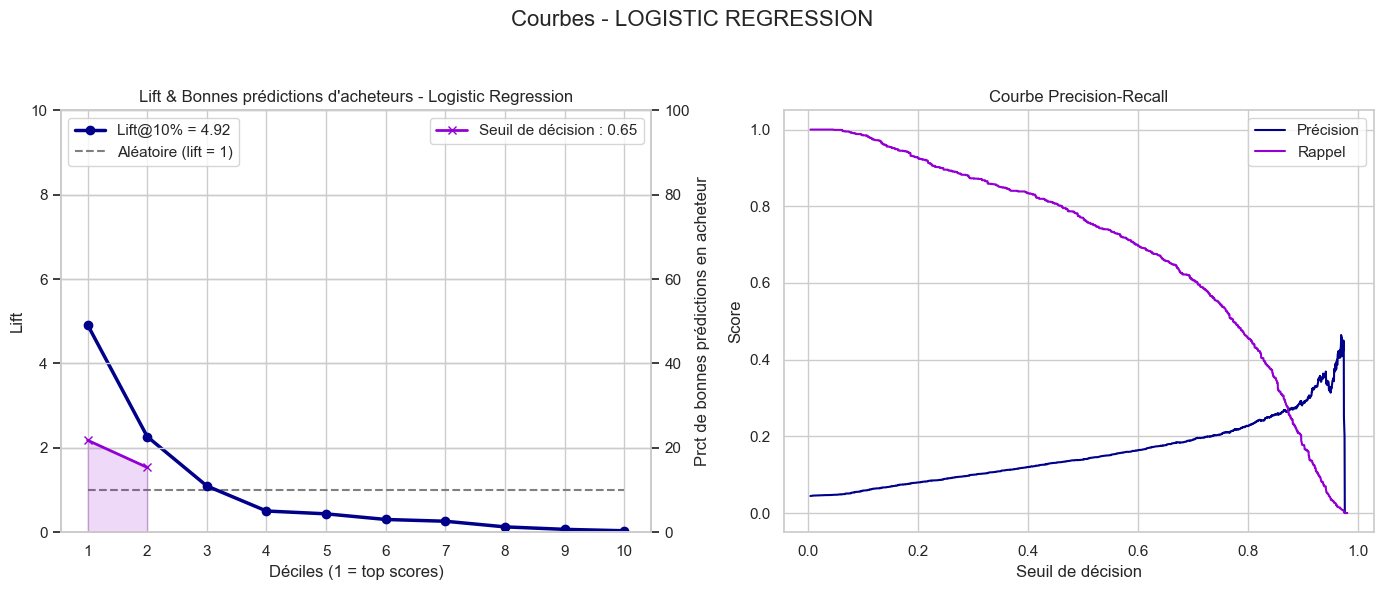

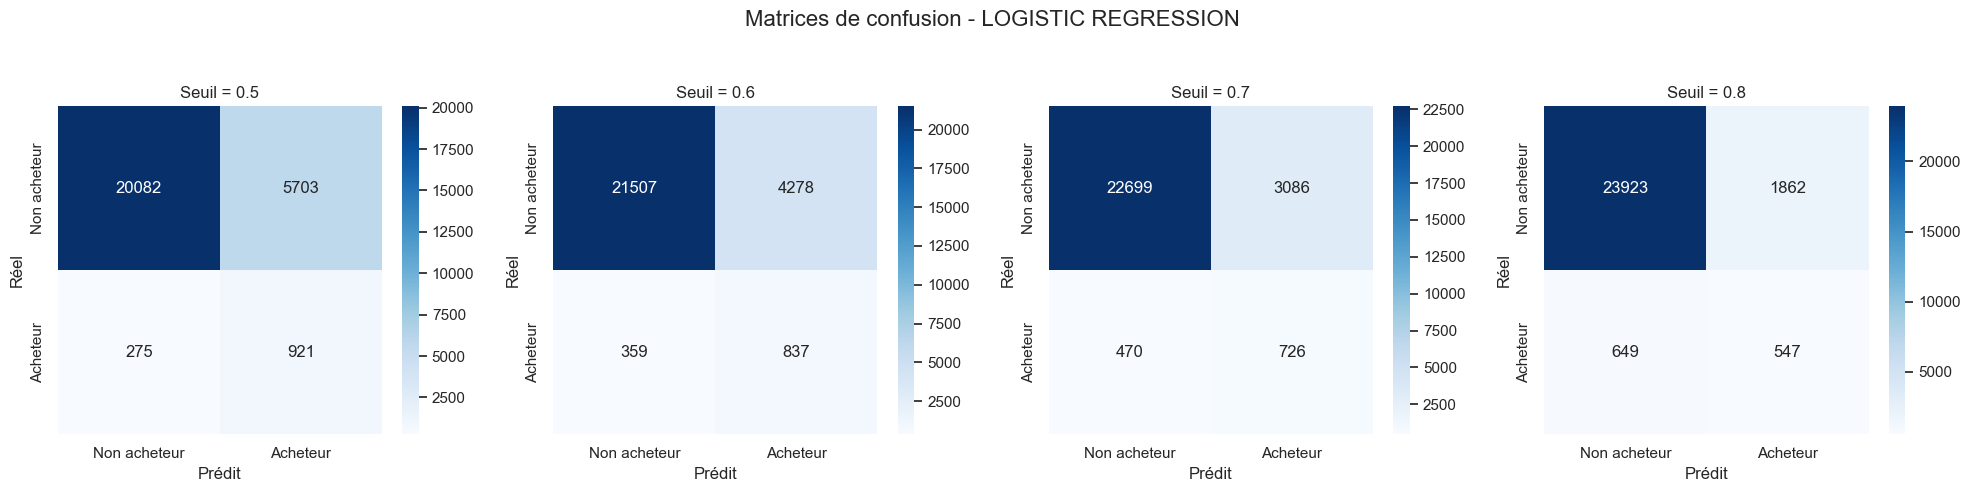

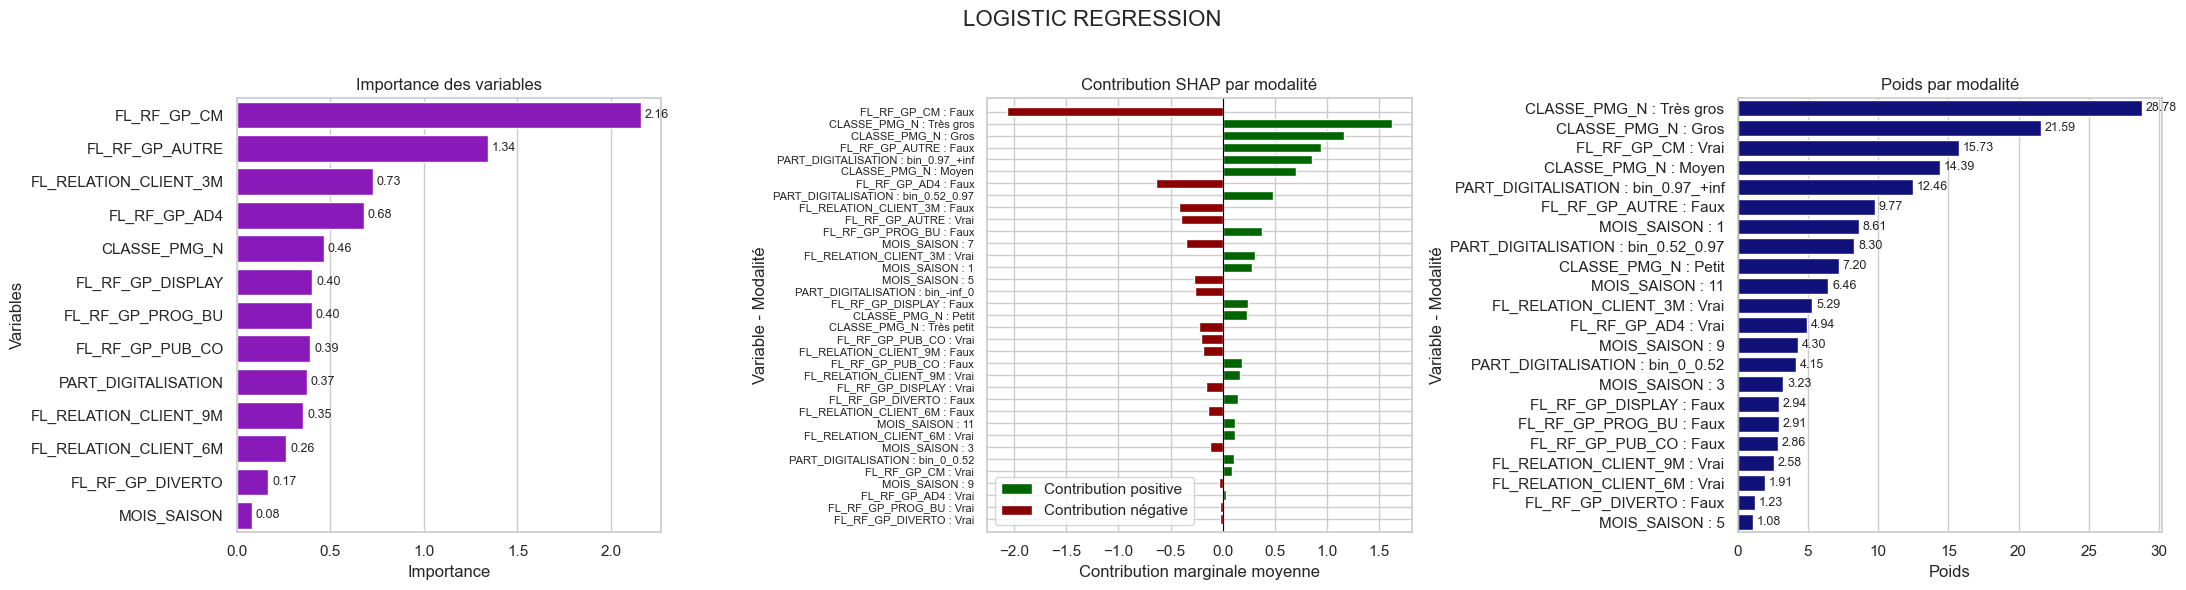

	 Modélisation Logistic Regression terminée.
---
---
	 Lancement de la modélisation Random Forest


In [ ]:
# Importations
## Import des librairies
import sys
import os
import pandas as pd 
import openpyxl
from datetime import datetime, date, timedelta
from dateutil.relativedelta import relativedelta

## Import du fichier environnement.py
sys.path.append(os.path.abspath("C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/_setup"))
import environnement as env

## Import du fichier d'importation des données
sys.path.append(os.path.abspath("C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/01_data_importation"))
from data_importation import cohortes

## Import du fichier de préparation des données à la modélisation
sys.path.append(os.path.abspath("C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/02_data_prepare_modelisation"))
from data_prepare_modelisation import apply_prepare_modelisation

## Import du fichier de modélisations
sys.path.append(os.path.abspath("C:/Users/prince.mezuirotimi/OneDrive - Gedeon - SIPAOF/Documents/INTRASIPA/PROJETS/ADDITI - SCORING APPETENCE PRODUIT/03_models"))
from models import run_models


"""
STRUCTURE DU PROJET :
_____________________________________________________________________________________________________________________________________________________
|----- main.py                                                                      <- fichier principal                                            |
|                                                                                                                                                   |
|   |----- data_importation.py$cohortes()                                           <- fichier de création de la base complète                      |
|   |   |----- requete.py$requete()                                                 <- fichier de requetage de la base                              |
|	|	|----- data_preprocessing.py$preprocessing()                                <- fichier de prétraitement de la base                          |
|	|	|----- data_new_indicators$create_new_indicators()                          <- fichier de création des nouveaux indicateurs                 |
|	|	|----- data_preprocessing.py$typage_columns()                               <- fichier de prétraitement de la base                          |
|                                                                                                                                                   |
|   |----- data_prepare_modelisation.py$apply_prepare_modelisation()                <- fichier de préparation à la modélisation                     |
|   |   |----- data_splitting.py$apply_splitting()                                  <- fichier de split du dataset train/val/test                   |
|   |   |----- data_discretization.py$apply_discretization()                        <- fichier de discretisation                                    |
|   |   |----- data_regroup_modalities.py$apply_regroup_modalities()                <- fichier de regroupement de modalités                         |
|   |   |----- features_preprocessing.py$apply_features_preprocessing()             <- fichier de standardisation et encoding des features          |
|   |   |----- data_sampling.py$apply_sampling()                                    <- fichier de ré-échantillonnage                                |
|___________________________________________________________________________________________________________________________________________________|
"""



if __name__ == "__main__":
    date_seuil_min = datetime.strptime("2022-01-01", "%Y-%m-%d")
    date_seuil_max = date.today().replace(day=1)
    current_date_heure = datetime.now().strftime('%Y%m%d_%Hh%M')
    
    # print('\tRécupération des produits cibles...')
    # Produits ciblés
        # on filtre sur les produits CIBL'AD+ = CIBLAGE + CIBL'AD
        # query qui repertory tous les produits vendus sur la période d'étude avec le nombre de ventes | pour filtrer les produits ciblés
            # pour respecter la casse on ajoute COLLATE Latin1_General_CS_AS avant le like
            
    query = f"""
    WITH PRODUITS_FILTERED AS (
        SELECT 
            CA.Id_offre,
            OFFRE.Libelle,
            COUNT(CA.reference) AS NB,
            CASE 
                WHEN (OFFRE.Libelle COLLATE Latin1_General_CS_AS LIKE '%Cibl%' AND LOWER(OFFRE.Libelle) NOT LIKE '%hors%')
                THEN 1 
                ELSE 0 
            END AS FL_PRODUIT_CIBLE
        FROM FAIT_APUB_PRESTATION_ANALYTIQUE AS CA
        LEFT JOIN (
            SELECT DISTINCT
                Id_offre,
                Libelle
            FROM DIM_OFFRE_PUB
        ) AS OFFRE ON OFFRE.Id_offre = CA.Id_offre
        WHERE CA.Date_facturation >= '2022-01-01' 
            AND CA.Date_facturation <= '2024-12-31'
            AND (CA.Id_etat_prestation IN ('APF', 'VLD') OR (CA.Id_etat_prestation = 'ATT' AND CA.Flag_motif_attente = 2048))
            AND CA.flag_regularisation <> 1 
        GROUP BY CA.Id_offre, OFFRE.Libelle
    )
    
    SELECT * FROM PRODUITS_FILTERED WHERE FL_PRODUIT_CIBLE = 1 AND NB > 0
    """
    produits = tuple(pd.DataFrame(env.sispub(query)).Id_offre)
    
    # Exporter la liste des produits dans un fichier Excel
    # produits_df = pd.DataFrame({'Id_offre': produits})
    # produits_df.to_excel(f'./00_archives/produits_{datetime.now().strftime("%Y%m%d_%Hh%M")}.xlsx', index=False)
    
    
    # Cohortes saisonnières
    # Variations saisonnières
    # start_date = datetime.strptime("2025-03-01", "%Y-%m-%d") # datetime.strptime("2022-01-01", "%Y-%m-%d") # // 2025 # // finalement 2023
    # database = cohortes(start_date=start_date,
    #                                     produits=produits,
    #                                     lag_prediction=3, # check lag_prediction=2,3,4,
    #                                     step=4)
    
    # Saisons identiques
    start_date = datetime.strptime("2022-11-01", "%Y-%m-%d")
    database = cohortes(start_date=start_date,
                                        produits=produits,
                                        lag_prediction=3, # check lag_prediction=2,4,
                                        step=2)
    
    # Cohortes mensuelles
    # start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    # database = cohortes(start_date=start_date,
    #                                     produits=produits,
    #                                     lag_prediction=3, # check lag_prediction=3,4,
    #                                     step=1)
        


    # Préparation des données pour la modélisation  
    data_train, data_val, data_test, dict_encode_mapping = apply_prepare_modelisation(df=database,
                                                                                        target='FL_ACHAT_PRODUIT',
                                                                                        verbose=True,
                                                                                        id_col='_ID_',
                                                                                        max_modalities=5,
                                                                                        woe_threshold=0.2,
                                                                                        criterion='AIC',
                                                                                        business_cols=['CLASSE_PMG_N', 'PART_DIGITALISATION', 'MOIS_SAISON'],
                                                                                        n_splits=5,
                                                                                        threshold_corr=0.7,
                                                                                        threshold_constant=0.99,
                                                                                        nb_max_features=30,
                                                                                        strate='FL_ACHAT_PRODUIT',
                                                                                        sampling_seuil_min=0.075,
                                                                                        sampling_mode='OVER'
                                                                                )
    
    # Sauvegarde des données
    database.to_csv(f'./00_archives/database{current_date_heure}.csv', sep=';', index=False, header=True, encoding='utf-8-sig')
    data_train.to_csv(f'./00_archives/data_train{current_date_heure}.csv', sep=';', index=True, header=True, encoding='utf-8-sig')
    data_val.to_csv(f'./00_archives/data_val{current_date_heure}.csv', sep=';', index=True, header=True, encoding='utf-8-sig')
    data_test.to_csv(f'./00_archives/data_test{current_date_heure}.csv', sep=';', index=True, header=True, encoding='utf-8-sig')
    

    # Test de modélisation
    models = run_models(data_train=data_train,
                                data_val=data_val,
                                data_test=data_test,
                                dict_encode_mapping=dict_encode_mapping,
                                target='FL_ACHAT_PRODUIT',
                                model_selected='all', # 'all' = 'logistic_regression', 'random_forest', 'xgboost'
                                threshold_decision=0.65,
                                beta=0.5,
                                lift_prct=10
                            )


    # Sauvergarde des modèles
    models_df = pd.DataFrame([
        {
            'model_name': model_info[0],                # model_name
            'model_sklearn': str(model_info[1]), # mdl (modèle sklearn converti en chaîne)
        }
        for model_info in models.values()
    ])
    models_df.to_excel(f'./00_archives/models_details_{current_date_heure}.xlsx', index=False)

    # Sauvegardes des grilles
    for model_info in models.values():
        scores_grid = model_info[2]
        scores_grid.to_csv(f'./00_archives/models_grid_{model_info[0]}_{current_date_heure}.csv', sep=';', index=True, header=True, encoding='utf-8-sig')